In [1]:
from picamera2 import Picamera2

import numpy as np
import time

#Picamera2 setup
cam = Picamera2()
width, height = 3280, 2464
RED_THRESHOLD = 200
RED_MIN_PERCENT = 75

cam.configure(
    cam.create_preview_configuration(
        main={"format": 'XRGB8888', "size": (width, height)}, display=None))
cam.start()

#Colour ranges for red and green in HSV colour spacew
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([160, 100, 100])
upper_red2 = np.array([180, 255, 255])

lower_green = np.array([35, 50, 50])
upper_green = np.array([85, 255, 255])

#The function that captures the image of the camera and checks if there is a a red or green obstacle on the image.
#Then it decides that it is red or green and returns it.
def get_thing():
    N_oszlop = 4
    N_sor = 4
    frame = cam.capture_array()
    height, width = frame.shape[:2]
    sormagassag = height // N_sor
    oszlopszelesseg = width // N_oszlop
    color = np.zeros((N_sor, N_oszlop))
    for i_oszlop in range(N_oszlop):
        for i_sor in range(N_sor):
            resz = frame[i_sor*sormagassag:(i_sor+1)*sormagassag, i_oszlop*oszlopszelesseg:(i_oszlop+1)*oszlopszelesseg, :]
            
            redmedian = np.median(resz[:, :, 2])
            greenmedian = np.median(resz[:, :, 1])
            bluemedian = np.median(resz[:, :, 0])
            
            # Zöld felismerése: zöld csatorna mediánja > kéké, zöld csatorna mediánja > pirosé, zöld csatorna mediánja > 100
            if redmedian < greenmedian and greenmedian > 100 and bluemedian < greenmedian:
                color[i_sor, i_oszlop] = 2
            # Piros felismerése: piros csatorna mediánja > 200, többié < 50
            if redmedian > 200 and greenmedian < 50 and bluemedian < 50:
                color[i_sor, i_oszlop] = 1

#    print('Piros:', np.sum(color==1), 'Zold:', np.sum(color==2))
#    print('Piros:', np.sum(color[:, :N_oszlop//2]==1), np.sum(color[:, N_oszlop//2:]==1))
#    print('Zold:', np.sum(color[:, :N_oszlop//2]==2), np.sum(color[:, N_oszlop//2:]==2))

    piros_van = (color[3*sormagassag:4*sormagassag] == 1).sum() > 1
    zold_van = (color[3*sormagassag:4*sormagassag] == 2).sum() > 1
    return piros_van, zold_van
    

[2:11:51.426173932] [13452]  INFO Camera camera_manager.cpp:340 libcamera v0.7.0+rpt20260205
[2:11:51.466742305] [13469]  INFO IPAProxy ipa_proxy.cpp:180 Using tuning file /usr/share/libcamera/ipa/rpi/vc4/imx219.json
[2:11:51.472689249] [13469]  INFO Camera camera_manager.cpp:223 Adding camera '/base/soc/i2c0mux/i2c@1/imx219@10' for pipeline handler rpi/vc4
[2:11:51.472741452] [13469]  INFO RPI vc4.cpp:445 Registered camera /base/soc/i2c0mux/i2c@1/imx219@10 to Unicam device /dev/media3 and ISP device /dev/media0
[2:11:51.472770247] [13469]  INFO RPI pipeline_base.cpp:1117 Using configuration file '/usr/share/libcamera/pipeline/rpi/vc4/rpi_apps.yaml'
[2:11:51.481515075] [13452]  INFO Camera camera.cpp:1215 configuring streams: (0) 3280x2464-XRGB8888/sRGB (1) 3280x2464-SBGGR10_CSI2P/RAW
[2:11:51.481938473] [13469]  INFO RPI vc4.cpp:620 Sensor: /base/soc/i2c0mux/i2c@1/imx219@10 - Selected sensor format: 3280x2464-SBGGR10_1X10/RAW - Selected unicam format: 3280x2464-pBAA/RAW


Piros: False, Zöld: False


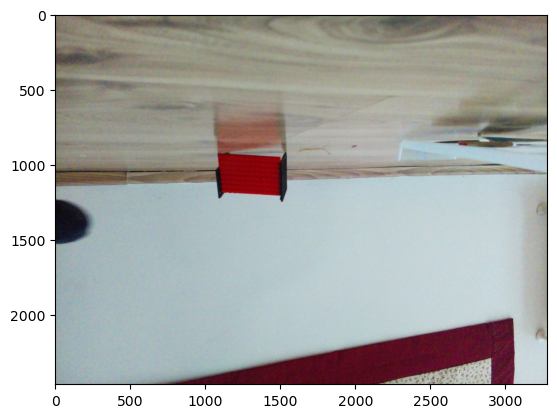

In [6]:
from matplotlib import pyplot as plt
piros, zold = get_thing()
print(f"Piros: {piros}, Zöld: {zold}")
plt.imshow(cam.capture_array()[:, :, 2::-1])
plt.show()